## <center>**Figure 01**</center>

In [1]:
# General
import os
import sys
from glob import glob

import numpy as np
import pandas as pd
from scipy.stats import pearsonr, linregress

# Connectome
import navis
import flybrains
import connectome_analysis_claude as ca

# Plots
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
sns.set_style("ticks")

from prats_helpers import place_panel_label

sys.path.append("../Scripts")
from _lineage_palette import (load_lineage_colors,
                              ANTERIOR_LINEAGES,
                              DORSO_POSTERIOR_LINEAGES)

HOME = os.environ["PROJECTS_HOME"]
SOMA_FOLDER = "../Analysis_Outputs/EM_Sections"

Loading in the Brain and the Tracts

In [2]:
brain    = flybrains.PK_L1CNSsym
neuropil = navis.Volume(flybrains.PK_L1CBNeuropilsym.mesh)
neuropil.color = (0.75, 0.75, 0.75, 0.2)

# Also the LONs
lonr = ca.stl_to_navis(f"{HOME}/L1_Compartment-Atlas/Central-Brain_Compartments/LON/LON_Right.stl")
lonl = ca.stl_to_navis(f"{HOME}/L1_Compartment-Atlas/Central-Brain_Compartments/LON/LON_Left.stl")

# Symmetrize
lonr = navis.xform_brain(lonr, source = "PK_L1CNS", target = "PK_L1CNSsym")
lonl = navis.xform_brain(lonl, source = "PK_L1CNS", target = "PK_L1CNSsym")
# Color
lonr.color = (0.75, 0.75, 0.75, 0.2)
lonl.color = (0.75, 0.75, 0.75, 0.2)

Transform path: PK_L1CNS -> PK_L1CNSsym
Transform path: PK_L1CNS -> PK_L1CNSsym


In [3]:
# Right skeletons
bamv3_skeletons = glob(f"{HOME}/L1_Skeletons/Skeletons/Diff_Skeletons/BAmv3/Right/*.swc")
bamv3_skeletons = navis.read_swc(bamv3_skeletons, fmt = "{id}.swc")

# Left tract
bamv3_tract = glob(f"{HOME}/L1_Skeletons/Skeletons/Diff_Tracts/BAmv3/Left/*.swc")
bamv3_tract = navis.read_swc(bamv3_tract, fmt = "{id}.swc")
for skel in bamv3_tract:
    skel.soma = None

# Color: skeletons green, tract grey
tract_color_dict = (dict(zip(bamv3_skeletons.id, ["green"] * len(bamv3_skeletons)))
                    | dict(zip(bamv3_tract.id,    ["grey"]  * len(bamv3_tract))))

# Symmetrize
bamv3_skeletons = navis.xform_brain(bamv3_skeletons, source = "PK_L1CNS", target = "PK_L1CNSsym")
bamv3_tract     = navis.xform_brain(bamv3_tract,     source = "PK_L1CNS", target = "PK_L1CNSsym")

Importing:   0%|          | 0/24 [00:00<?, ?it/s]

Importing:   0%|          | 0/24 [00:00<?, ?it/s]

Transform path: PK_L1CNS -> PK_L1CNSsym


Xforming:   0%|          | 0/24 [00:00<?, ?it/s]

Transform path: PK_L1CNS -> PK_L1CNSsym


Xforming:   0%|          | 0/24 [00:00<?, ?it/s]

In [4]:
lin_colors = load_lineage_colors(strip_slashes = False)

In [5]:
cb = ca.stl_to_navis(f"{HOME}/L1_Compartment-Atlas/Central-Brain_Compartments/Central_Brain_wCommissure.stl")
cb = navis.xform_brain(cb, source = "PK_L1CNS", target = "PK_L1CNSsym")

Transform path: PK_L1CNS -> PK_L1CNSsym


In [6]:
lineage_tract = glob(f"{HOME}/L1_Skeletons/Skeletons/Diff_Skeletons/*/*/*.swc")
lineage_tract = [t for t in lineage_tract if "S-" not in t and "Unbound" not in t]
lineage_tract = navis.read_swc(lineage_tract, fmt = "{id}.swc")

# Cut to cell-body-fiber and symmetrize
lineage_tract_cbf = navis.cell_body_fiber(lineage_tract, threshold = 0.5)
lineage_tract_cbf = navis.xform_brain(lineage_tract_cbf, source = "PK_L1CNS", target = "PK_L1CNSsym")
# lineage_tract_cbf = navis.in_volume(lineage_tract_cbf, volume = cb, mode = "IN")
lineage_tract_cbf = lineage_tract_cbf[lineage_tract_cbf.n_nodes > 15]

# Colorize: right = lineage color, left = greyed out
for skel in lineage_tract_cbf:
    if skel.hemisphere == "Right":
        color = lin_colors.get(skel.lineage, (0.5, 0.5, 0.5))
        skel.color = (*color[:3], 0.5)
    else:
        skel.color = (0.5, 0.5, 0.5, 0.15)

diff_color_dict = dict(zip(lineage_tract_cbf.id, lineage_tract_cbf.color))

# Group by anatomy
anterior_lineages = navis.NeuronList([s for s in lineage_tract_cbf if s.lineage in ANTERIOR_LINEAGES])
dp_lineages       = navis.NeuronList([s for s in lineage_tract_cbf if s.lineage in DORSO_POSTERIOR_LINEAGES])

Importing:   0%|          | 0/2721 [00:00<?, ?it/s]

Pruning:   0%|          | 0/2721 [00:00<?, ?it/s]

Transform path: PK_L1CNS -> PK_L1CNSsym


Xforming:   0%|          | 0/2721 [00:00<?, ?it/s]

In [7]:
su_tract = glob(f"{HOME}/L1_Skeletons/Skeletons/SU_Skeletons/*/Left/*.swc")
su_tract = [t for t in su_tract if "S-" not in t and "Unbound" not in t]
su_tract = navis.read_swc(su_tract, fmt = "{id}.swc")

# Symmetrize
su_tract = navis.xform_brain(su_tract, source = "PK_L1CNS", target = "PK_L1CNSsym")
# su_tract = navis.in_volume(su_tract, volume = cb, mode = "IN")
su_tract = su_tract[su_tract.n_nodes > 15]

for skel in su_tract:
    skel.color = (0, 0, 0, 0.5)

su_dict = dict(zip(su_tract.id, su_tract.color))

# Group by anatomy
anterior_su = navis.NeuronList([s for s in su_tract if s.lineage in ANTERIOR_LINEAGES])
dp_su       = navis.NeuronList([s for s in su_tract if s.lineage in DORSO_POSTERIOR_LINEAGES])

# Combined color dict
colors = diff_color_dict | su_dict

Importing:   0%|          | 0/518 [00:00<?, ?it/s]

Transform path: PK_L1CNS -> PK_L1CNSsym


Xforming:   0%|          | 0/518 [00:00<?, ?it/s]

Sensory Bundles

In [8]:
sensory = glob(f"{HOME}/L1_Skeletons/Skeletons/Diff_Skeletons/S-*/Right/*.swc")
bolwig  = glob(f"{HOME}/L1_Skeletons/Skeletons/Diff_Skeletons/BolwigsAxon/Right/*.swc")
sensory = navis.read_swc(sensory + bolwig, fmt = "{id}.swc")

# Setting up palette again
working_palette = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4',
                    '#42d4f4', '#f032e6', '#bfef45', '#fabed4', '#469990',
                    '#dcbeff', '#9A6324', '#800000', '#aaffc3', '#808000',
                    '#ffd8b1', '#000075', '#a9a9a9']
                    
pal = sns.color_palette(working_palette)
# Unique bundles
senses = np.unique(sensory.lineage)
cols = dict(zip(senses, pal))

# CellBodyFiber
sensory = navis.cell_body_fiber(sensory, threshold = 0.75)
for m in sensory:
    m.color = cols.get(m.lineage, "grey")

sensory_colors = dict(zip(sensory.id, sensory.color))

Importing:   0%|          | 0/215 [00:00<?, ?it/s]

Pruning:   0%|          | 0/215 [00:00<?, ?it/s]

Lineage Stats

In [9]:
count_df = pd.read_csv("../Analysis_Outputs/Lineage_Stats/Lineage_Counts.csv")

# Split off sensory / Bolwig counts
sensory_counts = count_df.loc[(count_df["Lineage"].str.contains("S-"))
                              | (count_df["Lineage"] == "Unbound")
                              | (count_df["Lineage"] == "BolwigsAxon")]
sensory_counts = sensory_counts.loc[sensory_counts["Category"] == "Diff"]

# Keep only lineage counts (remove sensory, Unbound, Bolwig)
count_df = count_df.loc[~(count_df["Lineage"].str.contains("S-"))
                        & (count_df["Lineage"] != "Unbound")
                        & ~(count_df["Lineage"].str.contains("Bolwigs"))]
count_df

,Lineage,Hemisphere,Category,Count
0,BAla1/2,Left,Dev,0
1,BAla1/2,Right,Dev,0
2,BAla3/4,Left,Dev,0
3,BAla3/4,Right,Dev,0
4,BAlc,Left,Dev,0
...,...,...,...,...
785,TRdm,Right,suNB,0
786,TRmotor,Left,suNB,0
787,TRmotor,Right,suNB,0
788,TRvm,Left,suNB,0


## Panel Stats

In [10]:
# Panel G - Differentiated counts, lineages present in both hemispheres
diff_right = count_df.loc[(count_df["Category"] == "Diff") & (count_df["Hemisphere"] == "Right")]
diff_left  = count_df.loc[(count_df["Category"] == "Diff") & (count_df["Hemisphere"] == "Left")]
diff_lr    = pd.merge(diff_right, diff_left, on = "Lineage", suffixes = ("_Right", "_Left"))

# Mean for the histogram
diff_mean = diff_lr[["Count_Right", "Count_Left"]].mean(axis = 1).mean()
diff_mean

15.651162790697674

In [11]:
# Panel H - SU counts, lineages present in both hemispheres
su_right = count_df.loc[(count_df["Category"] == "SU") & (count_df["Hemisphere"] == "Right")]
su_left  = count_df.loc[(count_df["Category"] == "SU") & (count_df["Hemisphere"] == "Left")]
su_lr    = pd.merge(su_right, su_left, on = "Lineage", suffixes = ("_Right", "_Left"))

# Mean for the histogram
su_mean = su_lr[["Count_Right", "Count_Left"]].mean(axis = 1).mean()
su_mean

5.941860465116279

In [12]:
# Panel I - Left vs Right correlations (uses diff_lr and su_lr from G and H)
r_diff, _          = pearsonr(diff_lr["Count_Right"], diff_lr["Count_Left"])
m_diff, b_diff, *_ = linregress(diff_lr["Count_Right"], diff_lr["Count_Left"])

r_su, _        = pearsonr(su_lr["Count_Right"], su_lr["Count_Left"])
m_su, b_su, *_ = linregress(su_lr["Count_Right"], su_lr["Count_Left"])

# Lineage with the max SU count (labelled on the plot)
peak = su_lr.sort_values(by = "Count_Right").iloc[-1]
r_diff, r_su, peak.Lineage

(0.9970963683398222, 0.9835075979701816, 'CM4')

In [13]:
# Panel J - Diff vs SU correlation by hemisphere
su_only   = count_df.loc[count_df["Category"] == "SU"  ].drop(["Category"], axis = 1)
diff_only = count_df.loc[count_df["Category"] == "Diff"].drop(["Category"], axis = 1)
diff_su   = pd.merge(su_only, diff_only,
                     on       = ["Lineage", "Hemisphere"],
                     suffixes = ("_SU", "_Diff"))

right_df = diff_su.loc[diff_su["Hemisphere"] == "Right"]
left_df  = diff_su.loc[diff_su["Hemisphere"] == "Left"]

r_right, _ = pearsonr(right_df["Count_Diff"], right_df["Count_SU"])
r_left, _  = pearsonr(left_df["Count_Diff"],  left_df["Count_SU"])
r_right, r_left

(0.4291228271360706, 0.472760826169458)

## Figure Layout

In [14]:
linewidth      = 0.75
scatter_size   = 6
scatter_alpha  = 0.75
linewidth_hist = 0.5
alpha_hist     = 0.35
title_fontsize = 8.5
label_fontsize = 7
tick_fontsize  = 6
labelpad       = 5
skel_alpha     = 0.25

# Coloring
diff_color = "purple"
su_color   = "#7CCD7C"

# Figure size
width  = 8.5
height = 9

# Anatomy panel limits (y inverted for the -y view); set on Ei, copied to Fi and Ki
anat_xlim = (2500, 102500)
anat_ylim = (102500, 2500)

# Lateral (ii) panels: z limits with the same span as Ei
# lateral_shift > 0 moves the brain to the left
lat_zlim      = (-6500, 93500)
lateral_shift = 15000

# Row labels (Anterior / Dorso-Posterior / Sensory), in dorsal-panel data coordinates
row_label_xy = (-2500, 102500 / 2)

# Panel C limits
c_xlim = (12500, 93000)
c_ylim = (85000, 5500)

# Panel resizing (figure fractions)
stat_shift          = 0.02   # G, I, L nudged left
extra_width_L       = 0.075  # L widened to the right
extra_panel_height  = 0.06   # Ki, Kii taller
extra_panel_C_width = 0.03   # C wider
extra_panel_left    = 0.03   # Ei, Ki widened to the left

In [15]:
# Some lineages for which we wnat to highlight the SU vs Diff counts 
selected_lins = ["CM4", "DPMm1", "DPMpm1", "DPMpm2", "DALcl1/2v"]

Plot neurons:   0%|          | 0/48 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/739 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/739 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/251 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/739 [00:00<?, ?it/s]

...

Plot neurons:   0%|          | 0/267 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/600 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/267 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/215 [00:00<?, ?it/s]

Plot neurons:   0%|          | 0/215 [00:00<?, ?it/s]

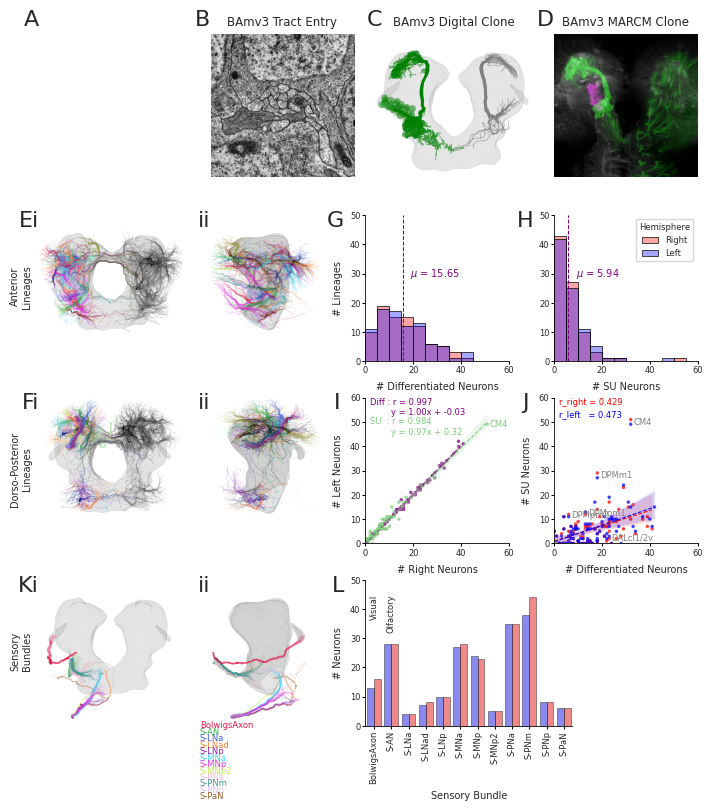

In [16]:
fig, ax = plt.subplots(figsize = (width, height),
                       nrows   = 4,
                       ncols   = 4)
plt.subplots_adjust(hspace = 0.25)
# Spine + tick styling
for a in ax.flatten():
    a.grid(False)
    for s in a.spines.values():
        s.set_color("black")
        s.set_linewidth(0.6)
        s.set_visible(True)

    a.tick_params(
        axis      = "both",
        which     = "major",
        color     = "black",
        labelsize = tick_fontsize,
        length    = 2,
        width     = 0.75,
        pad       = 1.5
    )

#------------------------------------------------------------------
# ROW 0 - Header panels (Schematic, EM, Clone, MARCM)
ax[0, 0].axis("off")

# Panel B - EM section
img = mpimg.imread(f"{SOMA_FOLDER}/BAmv3.png")
ax[0, 1].imshow(img, cmap = "grey")
ax[0, 1].set_title("BAmv3 Tract Entry", fontsize = title_fontsize)
ax[0, 1].axis("off")

# Panel C - BAmv3 digital clone
navis.plot2d([neuropil, lonr, lonl, bamv3_skeletons, bamv3_tract],
             ax        = ax[0, 2],
             method    = "2d",
             view      = ("x", "-y"),
             color     = tract_color_dict,
             linewidth = 0.6,
             alpha     = 0.5,
             rasterize = True)
# Match Ei limits and aspect so the brain renders at the same physical size
ax[0, 2].set_xlim(c_xlim)
ax[0, 2].set_ylim(c_ylim)
ax[0, 2].set_aspect("equal", adjustable = "datalim")
ax[0, 2].set_title("BAmv3 Digital Clone", fontsize = title_fontsize)
ax[0, 2].axis("off")

# Panel D - MARCM clone placeholder
img = mpimg.imread("MARCM_placeholder.png")
ax[0, 3].imshow(img)
ax[0, 3].set_title("BAmv3 MARCM Clone", fontsize = title_fontsize)
ax[0, 3].axis("off")

# Force row 0 panels to be square
for a in ax[0, :]:
    a.set_box_aspect(1)

#------------------------------------------------------------------
# ROW 1 col 0 - Anterior lineages, dorsal view
navis.plot2d([neuropil, lonr, lonl, anterior_lineages[anterior_lineages.hemisphere == "Right"]],
             ax        = ax[1, 0],
             method    = "2d",
             view      = ("x", "-y"),
             color     = colors,
             soma      = False,
             radius    = False,
             alpha     = skel_alpha,
             linewidth = 0.35,
             rasterize = True)

navis.plot2d([anterior_lineages[anterior_lineages.hemisphere == "Left"]],
             ax        = ax[1, 0],
             method    = "2d",
             view      = ("x", "-y"),
             color     = colors,
             soma      = False,
             radius    = False,
             alpha     = skel_alpha,
             linewidth = 0.35,
             rasterize = True)

navis.plot2d([anterior_su],
             ax        = ax[1, 0],
             method    = "2d",
             view      = ("x", "-y"),
             color     = colors,
             soma      = False,
             radius    = False,
             alpha     = skel_alpha,
             linewidth = 0.1,
             rasterize = True)

# Custom Limits
ax[1, 0].set_xlim(anat_xlim)
ax[1, 0].set_ylim(anat_ylim)

# Label
ax[1, 0].text(row_label_xy[0], row_label_xy[1],
              "Anterior\nLineages",
              ha = "right",
              va = "center",
              ma = "center",
              rotation = 90,
              fontsize = label_fontsize)

#------------------------------------------------------------------
# ROW 1 col 1 - Anterior lineages, lateral view
navis.plot2d([neuropil, lonr, lonl, anterior_lineages[anterior_lineages.hemisphere == "Right"]],
             ax        = ax[1, 1],
             method    = "2d",
             view      = ("z", "-y"),
             color     = colors,
             soma      = False,
             radius    = False,
             alpha     = skel_alpha,
             linewidth = 0.35,
             rasterize = True)

navis.plot2d([anterior_su],
             ax        = ax[1, 1],
             method    = "2d",
             view      = ("z", "-y"),
             color     = colors,
             soma      = False,
             radius    = False,
             alpha     = skel_alpha,
             linewidth = 0.09,
             rasterize = True)


#------------------------------------------------------------------
# ROW 2 col 0 - Dorso-posterior lineages, dorsal view
navis.plot2d([neuropil, lonr, lonl, dp_lineages[dp_lineages.hemisphere == "Right"]],
             ax        = ax[2, 0],
             method    = "2d",
             view      = ("x", "-y"),
             color     = colors,
             soma      = False,
             radius    = False,
             alpha     = skel_alpha,
             linewidth = 0.35,
             rasterize = True)

navis.plot2d([dp_lineages[dp_lineages.hemisphere == "Left"]],
             ax        = ax[2, 0],
             method    = "2d",
             view      = ("x", "-y"),
             color     = colors,
             soma      = False,
             radius    = False,
             alpha     = skel_alpha,
             linewidth = 0.35,
             rasterize = True)

navis.plot2d([dp_su],
             ax        = ax[2, 0],
             method    = "2d",
             view      = ("x", "-y"),
             color     = colors,
             soma      = False,
             radius    = False,
             alpha     = skel_alpha,
             linewidth = 0.1,
             rasterize = True)

# Label
ax[2, 0].text(row_label_xy[0], row_label_xy[1],
              "Dorso-Posterior\nLineages",
              ha = "right",
              va = "center",
              ma = "center",
              rotation = 90,
              fontsize = label_fontsize)


#------------------------------------------------------------------
# ROW 2 col 1 - Dorso-posterior lineages, lateral view
navis.plot2d([neuropil, lonr, lonl, dp_lineages[dp_lineages.hemisphere == "Right"]],
             ax        = ax[2, 1],
             method    = "2d",
             view      = ("z", "-y"),
             color     = colors,
             soma      = False,
             radius    = False,
             alpha     = skel_alpha,
             linewidth = 0.35,
             rasterize = True)

navis.plot2d([dp_su],
             ax        = ax[2, 1],
             method    = "2d",
             view      = ("z", "-y"),
             color     = colors,
             soma      = False,
             radius    = False,
             alpha     = skel_alpha,
             linewidth = 0.09,
             rasterize = True)


#------------------------------------------------------------------
# ROW 3 col 0 - Sensory bundles, dorsal view
navis.plot2d([neuropil, lonr, lonl, sensory],
             ax        = ax[3, 0],
             method    = "2d",
             view      = ("x", "-y"),
             color     = sensory_colors,
             soma      = False,
             radius    = False,
             linewidth = 0.35,
             alpha     = skel_alpha,
             rasterize = True)

# Label
ax[3, 0].text(row_label_xy[0], row_label_xy[1],
              "Sensory\nBundles",
              ha = "right",
              va = "center",
              ma = "center",
              rotation = 90,
              fontsize = label_fontsize)


#------------------------------------------------------------------
# ROW 3 col 1 - Sensory bundles, lateral view
navis.plot2d([neuropil, lonr, lonl, sensory],
             ax        = ax[3, 1],
             method    = "2d",
             view      = ("z", "-y"),
             color     = sensory_colors,
             soma      = False,
             radius    = False,
             linewidth = 0.35,
             alpha     = skel_alpha,
             rasterize = True)

# Adding labels
for i, (sen, c) in enumerate(cols.items()):
    ax[3, 1].text(1000, 105000 + (i * 4500), 
                  sen,
                  color = c,
                  fontsize = tick_fontsize)

#------------------------------------------------------------------
# Lock anatomy panel limits to the anterior-dorsal base
xlim = ax[1, 0].get_xlim()
ylim = ax[1, 0].get_ylim()

# Dorsal panels share xlim and ylim
for a in [ax[2, 0], ax[3, 0]]:
    a.set_xlim(xlim)
    a.set_ylim(ylim)

# Lateral panels: y stays, z limits shifted by lateral_shift
for a in [ax[1, 1], ax[2, 1], ax[3, 1]]:
    a.set_ylim(ylim)
    a.set_xlim(lat_zlim[0] + lateral_shift, lat_zlim[1] + lateral_shift)

# Equal aspect on all anatomy panels and turn axes off
for a in [ax[1, 0], ax[1, 1], ax[2, 0], ax[2, 1], ax[3, 0], ax[3, 1]]:
    a.set_aspect("equal", adjustable = "datalim")
    a.axis("off")

# Labels
# These get turned OFF when we turn off axes
ax[1, 0].set_ylabel("Anterior\nLineages", fontsize = title_fontsize)
ax[2, 0].set_ylabel("Dorso-Posterior\nLineages", fontsize = title_fontsize)

#------------------------------------------------------------------
# ROW 1 col 2 - Differentiated counts histogram (L vs R)
for hemi, color in [("Right", "red"), ("Left", "blue")]:
    sns.histplot(
        data      = count_df.loc[(count_df["Category"] == "Diff") & (count_df["Hemisphere"] == hemi)],
        x         = "Count",
        ax        = ax[1, 2],
        color     = color,
        label     = hemi,
        alpha     = alpha_hist,
        linewidth = linewidth_hist,
        edgecolor = "black",
        binwidth  = 5,
        binrange  = (0, 60))

ax[1, 2].set_xlabel("# Differentiated Neurons", fontsize = label_fontsize, labelpad = labelpad)
ax[1, 2].set_ylabel("# Lineages",               fontsize = label_fontsize, labelpad = labelpad)
ax[1, 2].set_xlim(0, 60)
ax[1, 2].set_ylim(0, 50)

#------------------------------------------------------------------
# ROW 1 col 3 - SU counts histogram (L vs R)
for hemi, color in [("Right", "red"), ("Left", "blue")]:
    sns.histplot(
        data      = count_df.loc[(count_df["Category"] == "SU") & (count_df["Hemisphere"] == hemi)],
        x         = "Count",
        ax        = ax[1, 3],
        color     = color,
        label     = hemi,
        alpha     = alpha_hist,
        linewidth = linewidth_hist,
        edgecolor = "black",
        binwidth  = 5,
        binrange  = (0, 60))

ax[1, 3].set_xlabel("# SU Neurons", fontsize = label_fontsize, labelpad = labelpad)
# Shared label with previous item
ax[1, 3].set_ylabel("",   fontsize = label_fontsize, labelpad = labelpad)
ax[1, 3].set_xlim(0, 60)
ax[1, 3].set_ylim(0, 50)
ax[1, 3].legend(title          = "Hemisphere",
                loc            = "upper right",
                bbox_to_anchor = (1, 1),
                fontsize       = tick_fontsize,
                title_fontsize = tick_fontsize)


#------------------------------------------------------------------
# ROW 2 col 2 - Combined L vs R for Diff (purple) and SU (light green)
# Diff
sns.regplot(data        = diff_lr,
            x           = "Count_Right",
            y           = "Count_Left",
            ax          = ax[2, 2],
            scatter_kws = {"alpha": scatter_alpha, "color": diff_color,
                           "s": scatter_size, "edgecolor": "none"},
            line_kws    = {"color": diff_color, "linewidth": linewidth, "linestyle": "--"},
            label       = "Diff")

# SU
sns.regplot(data        = su_lr,
            x           = "Count_Right",
            y           = "Count_Left",
            ax          = ax[2, 2],
            scatter_kws = {"alpha": scatter_alpha, "color": su_color,
                           "s": scatter_size, "edgecolor": "none"},
            line_kws    = {"color": su_color, "linewidth": linewidth, "linestyle": "--"},
            label       = "SU")

ax[2, 2].set_xlim(0, 60)
ax[2, 2].set_ylim(0, 60)
ax[2, 2].set_xlabel("# Right Neurons", fontsize = label_fontsize, labelpad = labelpad)
ax[2, 2].set_ylabel("# Left Neurons",  fontsize = label_fontsize, labelpad = labelpad)

# Add label for max SU count
ax[2, 2].text(peak.Count_Right + 1, peak.Count_Left,
              peak.Lineage,
              ha = "left", va = "center",
              color = su_color,
              fontsize = tick_fontsize)

#------------------------------------------------------------------
# Stats
ax[2, 2].text(2, 60,
              f"Diff : r = {r_diff:.3f}\n        y = {m_diff:.2f}x + {b_diff:.2f}",
              color    = diff_color,
              va       = "top",
              ha       = "left",
              fontsize = tick_fontsize)
ax[2, 2].text(2, 52,
              f"SU  : r = {r_su:.3f}\n        y = {m_su:.2f}x + {b_su:.2f}",
              color    = su_color,
              va       = "top",
              ha       = "left",
              fontsize = tick_fontsize)

# Mean lines back on the histograms above
ax[1, 2].axvline(diff_mean, color = "purple", linewidth = linewidth, linestyle = "--")
ax[1, 2].text(diff_mean + 3, 30,
              f"$\mu$ = {diff_mean:.2f}",
              color    = "purple",
              fontsize = label_fontsize,
              va       = "center")

ax[1, 3].axvline(su_mean, color = "purple", linewidth = linewidth, linestyle = "--")
ax[1, 3].text(su_mean + 3, 30,
              f"$\mu$ = {su_mean:.2f}",
              color    = "purple",
              fontsize = label_fontsize,
              va       = "center")

#------------------------------------------------------------------
# ROW 2 col 3 - Diff vs SU correlation by hemisphere
for df, color, label in [(right_df, "red", "Right"), (left_df, "blue", "Left")]:
    sns.regplot(data        = df,
                x           = "Count_Diff",
                y           = "Count_SU",
                ax          = ax[2, 3],
                scatter_kws = {"alpha": scatter_alpha, "color": color,
                               "s": scatter_size, "edgecolor": "none"},
                line_kws    = {"color": color, "linewidth": linewidth, "linestyle": "--"},
                label       = label)

ax[2, 3].set_xlim(0, 60)
ax[2, 3].set_ylim(0, 60)
ax[2, 3].set_xlabel("# Differentiated Neurons", fontsize = label_fontsize, labelpad = labelpad)
ax[2, 3].set_ylabel("# SU Neurons",             fontsize = label_fontsize, labelpad = labelpad)
ax[2, 3].text(2, 60,
              f"r_right = {r_right:.3f}",
              va       = "top",
              ha       = "left",
              color    = "red",
              fontsize = tick_fontsize)

ax[2, 3].text(2, 55,
              f"r_left   = {r_left:.3f}",
              va       = "top",
              ha       = "left",
              color    = "blue",
              fontsize = tick_fontsize)

# Adding pieces
for lin in selected_lins:
    item = diff_su.loc[diff_su["Lineage"] == lin]
    # Get the mean
    y = item.Count_SU.mean()
    x = item.Count_Diff.max() + 1
    # Place text
    ax[2, 3].text(x, y,
                  lin,
                  color    = "grey",
                  fontsize = tick_fontsize,
                  ha       = "left",
                  va       = "center")

#------------------------------------------------------------------
# ROW 3 col 2 - Sensory bundle counts
sns.barplot(sensory_counts,
            x         = "Lineage",
            y         = "Count",
            hue       = "Hemisphere",
            order     = senses,
            ax        = ax[3, 2],
            palette   = {"Right": "red", "Left": "blue"},
            alpha     = alpha_hist * 1.5,
            edgecolor = "black",
            linewidth = linewidth_hist,
            legend    = False)

ax[3, 2].set_xlabel("Sensory Bundle", fontsize = label_fontsize, labelpad = labelpad)
ax[3, 2].set_ylabel("# Neurons",      fontsize = label_fontsize, labelpad = labelpad)
ax[3, 2].set_ylim(0, 50)
ax[3, 2].tick_params(axis      = "x",
                     which     = "major",
                     labelsize = tick_fontsize,
                     rotation  = 90)

# Texts
ax[3, 2].text(0, 45,
              s  = "Visual",
              ha = "center",
              va = "top",
              fontsize = tick_fontsize,
              rotation = 90)

ax[3, 2].text(1, 45,
              s  = "Olfactory",
              ha = "center",
              va = "top",
              fontsize = tick_fontsize,
              rotation = 90)

# Unused panel
ax[3, 3].axis("off")

#------------------------------------------------------------------
# Despine the stat panels
for a in [ax[1, 2], ax[1, 3], ax[2, 2], ax[2, 3], ax[3, 2]]:
    sns.despine(ax = a)

#------------------------------------------------------------------
# Nudge F, I slightly left
for a in [ax[1, 2], ax[2, 2], ax[3, 2]]:
    pos = a.get_position()
    a.set_position([pos.x0 - stat_shift, pos.y0, pos.width, pos.height])

# Widen L while keeping its left edge in place
pos = ax[3, 2].get_position()
ax[3, 2].set_position([pos.x0, pos.y0, pos.width + extra_width_L, pos.height])

#------------------------------------------------------------------
# Panel labels
label_kwargs = dict(fontsize = 16, va = "bottom", ha = "right")
shy = 0.005
place_panel_label(fig, ax[0, 0], "A", shx = 0, shy = shy, label_kwargs = label_kwargs)
place_panel_label(fig, ax[0, 1], "B", shx = 0, shy = shy, label_kwargs = label_kwargs)
place_panel_label(fig, ax[0, 2], "C", shx = 0, shy = shy, label_kwargs = label_kwargs)
place_panel_label(fig, ax[0, 3], "D", shx = 0, shy = shy, label_kwargs = label_kwargs)

label_kwargs["va"] = "top"
place_panel_label(fig, ax[1, 0], "Ei",  shx = 0, shy = shy, label_kwargs = label_kwargs)
place_panel_label(fig, ax[1, 1], "ii",  shx = 0, shy = shy, label_kwargs = label_kwargs)
place_panel_label(fig, ax[1, 2], "G",   shx = -0.025, shy = shy, label_kwargs = label_kwargs)
place_panel_label(fig, ax[1, 3], "H",   shx = -0.025, shy = shy, label_kwargs = label_kwargs)

place_panel_label(fig, ax[2, 0], "Fi",  shx = 0, shy = shy, label_kwargs = label_kwargs)
place_panel_label(fig, ax[2, 1], "ii",  shx = 0, shy = shy, label_kwargs = label_kwargs)
place_panel_label(fig, ax[2, 2], "I",   shx = -0.03, shy = shy, label_kwargs = label_kwargs)
place_panel_label(fig, ax[2, 3], "J",   shx = -0.03, shy = shy, label_kwargs = label_kwargs)

place_panel_label(fig, ax[3, 0], "Ki",  shx = 0, shy = shy, label_kwargs = label_kwargs)
place_panel_label(fig, ax[3, 1], "ii",  shx = 0, shy = shy, label_kwargs = label_kwargs)
place_panel_label(fig, ax[3, 2], "L",   shx = -0.025, shy = shy, label_kwargs = label_kwargs)

#------------------------------------------------------------------
# This is done after label placement (otherwise they will be off)
# Grow Ki and Kii vertically; scale ylim by the same factor so the neuropil
# keeps its physical size (data-units-per-inch unchanged on y)
# All this is also cleaned up manually later
for a in [ax[3, 0], ax[3, 1]]:
    pos       = a.get_position()
    y0_lim, y1_lim = a.get_ylim()
    y_mid     = (y0_lim + y1_lim) / 2
    y_half    = (y1_lim - y0_lim) / 2
    scale     = (pos.height + extra_panel_height) / pos.height
    a.set_position([pos.x0,
                    pos.y0 - extra_panel_height / 2,
                    pos.width,
                    pos.height + extra_panel_height])
    a.set_ylim(y_mid - y_half * scale, y_mid + y_half * scale)

# Widen panel C; scale xlim by the same factor so the brain keeps its physical size
pos       = ax[0, 2].get_position()
x0_lim, x1_lim = ax[0, 2].get_xlim()
x_mid     = (x0_lim + x1_lim) / 2
x_half    = (x1_lim - x0_lim) / 2
scale     = (pos.width + extra_panel_C_width) / pos.width
ax[0, 2].set_box_aspect(None)
ax[0, 2].set_position([pos.x0 - extra_panel_C_width / 2,
                       pos.y0,
                       pos.width + extra_panel_C_width,
                       pos.height])
ax[0, 2].set_xlim(x_mid - x_half * scale, x_mid + x_half * scale)

#------------------------------------------------------------------
# Widen Ei and Ki to the left; scale xlim by the same factor so the neuropil
# keeps its physical size (data-units-per-inch unchanged on x)
for a in [ax[1, 0], ax[3, 0]]:
    pos       = a.get_position()
    x0_lim, x1_lim = a.get_xlim()
    x_range   = x1_lim - x0_lim
    scale     = (pos.width + extra_panel_left) / pos.width
    a.set_position([pos.x0 - extra_panel_left,
                    pos.y0,
                    pos.width + extra_panel_left,
                    pos.height])
    new_range = x_range * scale
    a.set_xlim(x1_lim - new_range, x1_lim)

#------------------------------------------------------------------
plt.savefig("../Analysis_Outputs/Figure_01.pdf",
            bbox_inches = "tight",
            dpi         = 1200)

# <center>**हो गया दोस्तों!!!**</center>